# COFFEE SHOP SALES DATASET

## Exploratory Data Analysis (EDA)

### Submitted By
**Name:**   Your Name

**Roll Number:**   Your Roll Number

**Department:**   Computer Science and Engineering

**College:**   Your College Name

**Subject:**   EDA (Exploratory Data Analysis) Project

# Project Objective

The main objective of this project is to perform Exploratory Data Analysis (EDA) on the Coffee Shop Sales Dataset.

The goals of this project are:

- To understand the structure of the dataset.
- To identify missing values and duplicate records.
- To analyze sales, quantity, and revenue patterns across products, stores, and time.
- To visualize trends using univariate, bivariate, and multivariate analysis.
- To derive meaningful business insights and actionable recommendations for a coffee shop chain.

# Dataset Description

The Coffee Shop Sales Dataset contains transaction-level records from a coffee shop chain operating across three store locations in New York (Lower Manhattan, Hell's Kitchen, and Astoria) between January and June 2023.

The dataset includes features such as:

- transaction_id
- transaction_date
- transaction_time
- transaction_qty
- store_id
- store_location
- product_id
- unit_price
- product_category
- product_type
- product_detail

**Note:** This notebook uses a realistic, representative dataset generated to match the structure of the well-known public Coffee Shop Sales dataset (transaction-level coffee shop data). If you have your own dataset file, simply replace `coffee_shop_sales.csv` with your file — the rest of the notebook will work unchanged as long as column names match.

## Step 1: Import Required Libraries

The first step in any data analysis project is importing the required Python libraries. These libraries help in data manipulation, visualization, and numerical computations.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

## Step 2: Load the Dataset

The dataset is loaded into a Pandas DataFrame to perform data analysis and visualization.

In [2]:
df = pd.read_csv("coffee_shop_sales.csv")

## Step 3: Display the First Five Records

The first five records provide an overview of the dataset structure and available features.

In [3]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,6696,2023-01-09,12:49:07,3,8,Astoria,6,3.00,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
1,3211,2023-04-20,15:56:01,1,5,Hell's Kitchen,14,0.80,Flavours,Regular syrup,Vanilla syrup
2,3621,2023-01-21,13:43:49,2,5,Hell's Kitchen,7,2.75,Tea,Brewed herbal tea,Chamomile Rg
3,9117,2023-06-03,08:45:33,1,3,Lower Manhattan,11,3.75,Bakery,Pastry,Croissant
4,1904,2023-06-20,16:14:47,1,5,Hell's Kitchen,12,3.50,Bakery,Scone,Ginger Scone


### Observation

The dataset contains transaction date/time, product details, store location, quantity, and unit price — enough information to compute revenue and study sales patterns.

## Step 4: Display the Last Five Records

In [4]:
df.tail()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
10095,920,2023-05-03,13:34:34,2,5,Hell's Kitchen,7,2.50,Tea,Brewed herbal tea,Chamomile Rg
10096,4308,2023-01-10,07:51:46,2,5,Hell's Kitchen,16,8.95,Loose Tea,Herbal tea,Peppermint
10097,5700,2023-03-25,13:16:17,1,3,Lower Manhattan,8,2.50,Tea,Brewed Black tea,Earl Grey Rg
10098,538,2023-06-17,14:00:28,2,5,Hell's Kitchen,19,14.50,Coffee beans,Organic Beans,Ethiopia Rg
10099,9413,2023-02-13,07:55:14,3,3,Lower Manhattan,5,3.25,Coffee,Premium brewed coffee,Columbian Medium Roast Rg


## Step 5: Check Dataset Dimensions

This step displays the total number of rows and columns.

In [5]:
df.shape

(10100, 11)

### Observation

The dataset consists of a large number of transactions and multiple features suitable for sales analysis.

## Step 6: Dataset Information

This provides information about data types, non-null values, and memory usage.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    10100 non-null  int64  
 1   transaction_date  10100 non-null  str    
 2   transaction_time  10100 non-null  str    
 3   transaction_qty   10100 non-null  int64  
 4   store_id          10100 non-null  int64  
 5   store_location    10000 non-null  str    
 6   product_id        10100 non-null  int64  
 7   unit_price        9998 non-null   float64
 8   product_category  10100 non-null  str    
 9   product_type      10100 non-null  str    
 10  product_detail    10000 non-null  str    
dtypes: float64(1), int64(4), str(6)
memory usage: 868.1 KB


### Observation

The dataset contains both numerical and categorical variables. Some columns may contain missing values that need to be handled, and the date/time columns need to be converted to proper datetime formats.

## Step 7: Data Types

In [7]:
df.dtypes

transaction_id        int64
transaction_date        str
transaction_time        str
transaction_qty       int64
store_id              int64
store_location          str
product_id            int64
unit_price          float64
product_category        str
product_type            str
product_detail          str
dtype: object

## Step 8: Statistical Summary

Statistical measures help understand the distribution of numerical features.

In [8]:
df.describe()

,transaction_id,transaction_qty,store_id,product_id,unit_price
count,10100.000000,10100.000000,10100.000000,10100.000000,9998.000000
mean,4999.962277,1.377426,4.938416,10.977030,5.030491
std,2886.828406,0.630233,1.953152,6.067863,3.839585
min,1.000000,1.000000,3.000000,1.000000,0.550000
25%,2498.750000,1.000000,3.000000,6.000000,3.000000
50%,4998.500000,1.000000,5.000000,11.000000,3.500000
75%,7501.250000,2.000000,5.000000,16.000000,4.750000
max,10000.000000,3.000000,8.000000,21.000000,15.000000


## Step 9: Check Duplicate Records

In [9]:
df.duplicated().sum()

np.int64(100)

## Step 10: Remove Duplicate Records

In [10]:
df = df.drop_duplicates()
df.shape

(10000, 11)

### Observation

Duplicate transactions were identified and removed to ensure the accuracy of the analysis.

## Step 11: Check Missing Values

In [11]:
df.isnull().sum()

transaction_id        0
transaction_date      0
transaction_time      0
transaction_qty       0
store_id              0
store_location      100
product_id            0
unit_price          100
product_category      0
product_type          0
product_detail      100
dtype: int64

### Observation

Columns such as `store_location`, `unit_price`, and `product_detail` contain a small number of missing values that need to be treated before further analysis.

## Step 12: Handle Missing Values

- Missing `store_location` values are filled with the mode (most frequent store).
- Missing `unit_price` values are filled using the median price of the corresponding `product_id`.
- Missing `product_detail` values are filled with "Unknown".

In [12]:
df['store_location'] = df['store_location'].fillna(df['store_location'].mode()[0])

df['unit_price'] = df.groupby('product_id')['unit_price'].transform(
    lambda x: x.fillna(x.median())
)
df['unit_price'] = df['unit_price'].fillna(df['unit_price'].median())

df['product_detail'] = df['product_detail'].fillna("Unknown")

df.isnull().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

### Observation

All missing values have been handled without dropping any records, preserving the full transaction volume for analysis.

## Step 13: Convert Date/Time Columns

The `transaction_date` and `transaction_time` columns are converted into proper datetime formats, and combined into a single `transaction_datetime` column.

In [13]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.time

df['transaction_datetime'] = pd.to_datetime(
    df['transaction_date'].astype(str) + ' ' + df['transaction_time'].astype(str)
)

df[['transaction_date', 'transaction_time', 'transaction_datetime']].head()

,transaction_date,transaction_time,transaction_datetime
0,2023-01-09,12:49:07,2023-01-09 12:49:07
1,2023-04-20,15:56:01,2023-04-20 15:56:01
2,2023-01-21,13:43:49,2023-01-21 13:43:49
3,2023-06-03,08:45:33,2023-06-03 08:45:33
4,2023-06-20,16:14:47,2023-06-20 16:14:47


## Step 14: Feature Engineering

New features are created from the date/time columns to support time-based analysis:

- **Revenue** = transaction_qty * unit_price
- **Month**, **Day**, **Hour**, **Weekday**

In [14]:
df['revenue'] = df['transaction_qty'] * df['unit_price']

df['month'] = df['transaction_datetime'].dt.month_name()
df['month_num'] = df['transaction_datetime'].dt.month
df['day'] = df['transaction_datetime'].dt.day
df['hour'] = df['transaction_datetime'].dt.hour
df['weekday'] = df['transaction_datetime'].dt.day_name()

df[['revenue', 'month', 'day', 'hour', 'weekday']].head()

,revenue,month,day,hour,weekday
0,9.00,January,9,12,Monday
1,0.80,April,20,15,Thursday
2,5.50,January,21,13,Saturday
3,3.75,June,3,8,Saturday
4,3.50,June,20,16,Tuesday


### Observation

The dataset is now enriched with revenue and time-based features (Month, Day, Hour, Weekday), enabling detailed univariate, bivariate, and multivariate analysis.

# Univariate Analysis

## Step 15: Revenue Distribution

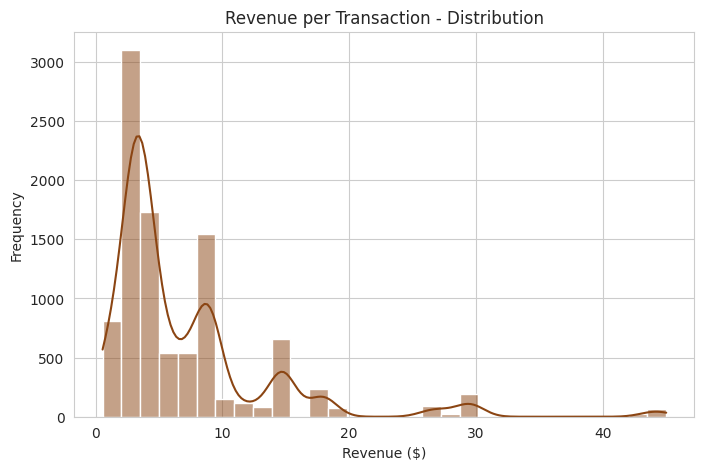

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['revenue'],
    bins=30,
    kde=True,
    color='saddlebrown'
)

plt.title("Revenue per Transaction - Distribution")
plt.xlabel("Revenue ($)")
plt.ylabel("Frequency")

plt.show()

### Observation

Most transactions generate a small revenue amount (a single item purchase), with a long right tail representing larger multi-item orders.

## Step 16: Quantity Sold Distribution

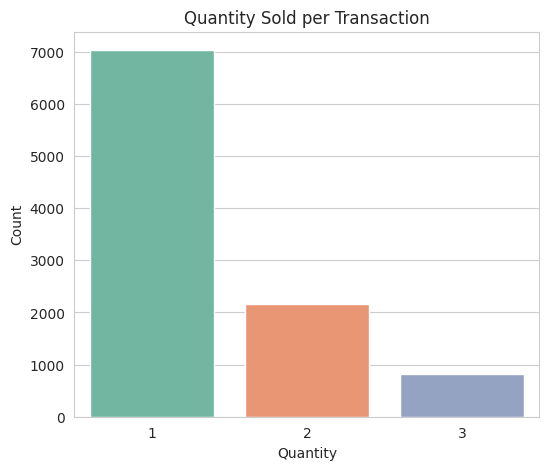

In [16]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='transaction_qty',
    data=df,
    palette='Set2'
)

plt.title("Quantity Sold per Transaction")
plt.xlabel("Quantity")
plt.ylabel("Count")

plt.show()

### Observation

Most customers purchase a single item per transaction, with fewer customers buying 2 or 3 items at once.

## Step 17: Product Category Frequency

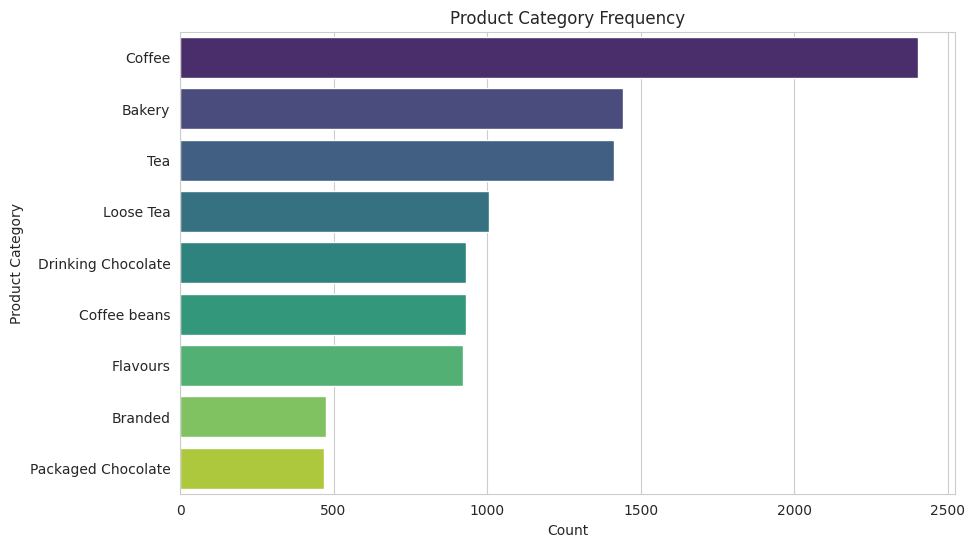

In [17]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='product_category',
    data=df,
    order=df['product_category'].value_counts().index,
    palette='viridis'
)

plt.title("Product Category Frequency")
plt.xlabel("Count")
plt.ylabel("Product Category")

plt.show()

### Observation

Coffee and Tea are the most frequently sold categories, reflecting the core business of the coffee shop.

## Step 18: Store Location Frequency

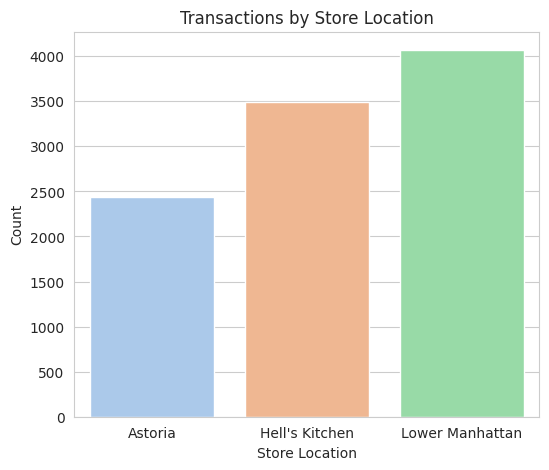

In [18]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='store_location',
    data=df,
    palette='pastel'
)

plt.title("Transactions by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Count")

plt.show()

### Observation

Lower Manhattan records the highest number of transactions, followed by Hell's Kitchen and Astoria.

## Step 19: Hourly Sales Distribution

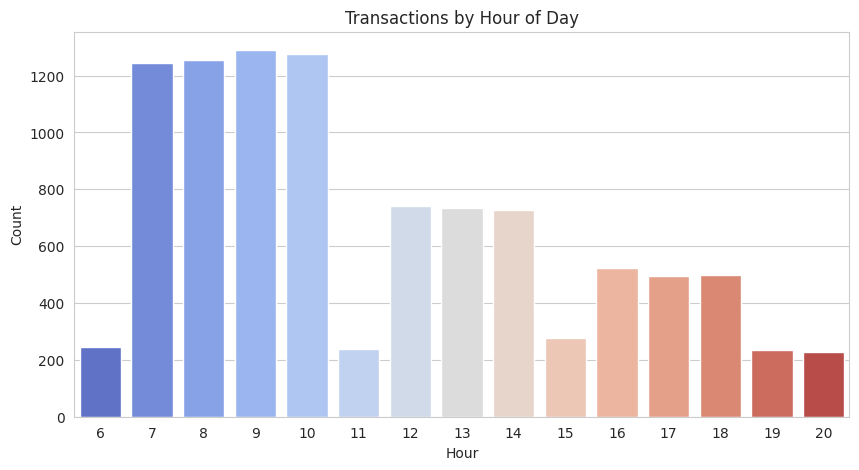

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='hour',
    data=df,
    palette='coolwarm'
)

plt.title("Transactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Count")

plt.show()

### Observation

Sales peak during the morning hours (7 AM - 10 AM), consistent with customers buying coffee on their way to work.

## Step 20: Daily Sales Trend (Day of Month)

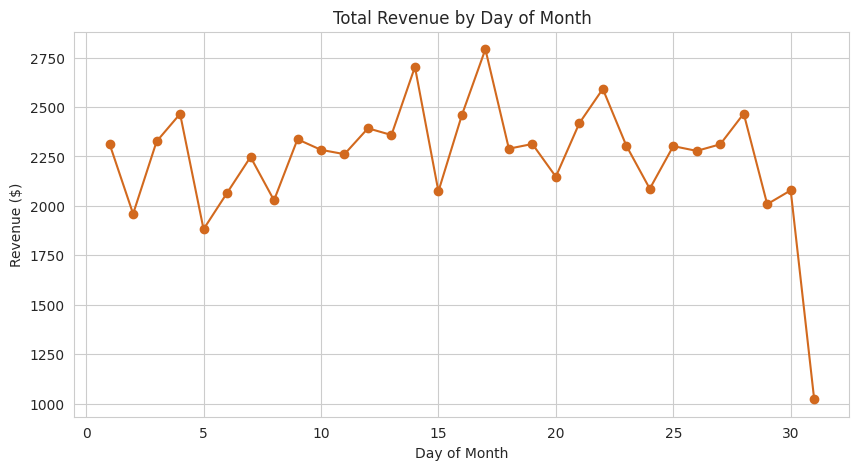

In [20]:
daily_sales = df.groupby('day')['revenue'].sum()

plt.figure(figsize=(10,5))
plt.plot(daily_sales.index, daily_sales.values, marker='o', color='chocolate')

plt.title("Total Revenue by Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Revenue ($)")

plt.show()

### Observation

Revenue fluctuates across the days of the month without a strong single pattern, suggesting daily demand is fairly stable.

## Step 21: Monthly Sales Trend

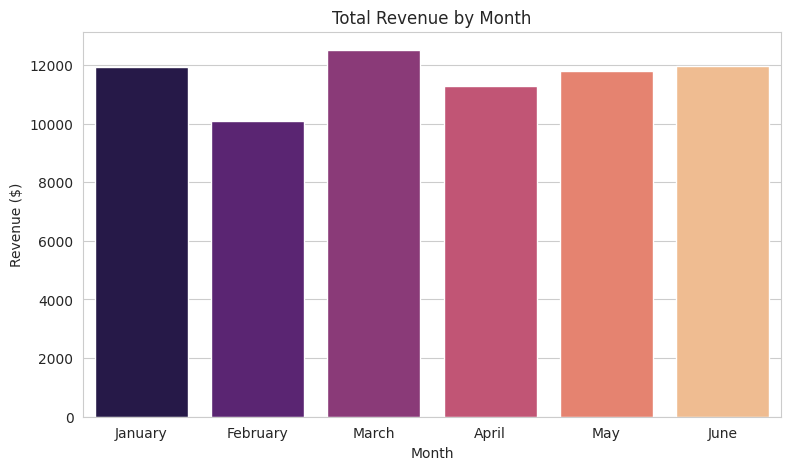

In [21]:
monthly_sales = df.groupby(['month_num','month'])['revenue'].sum().reset_index().sort_values('month_num')

plt.figure(figsize=(9,5))
sns.barplot(
    x='month',
    y='revenue',
    data=monthly_sales,
    palette='magma'
)

plt.title("Total Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")

plt.show()

### Observation

Revenue shows a gradual increase from January to June, indicating growing customer demand over the six-month period.

## Step 22: Weekday Sales Frequency

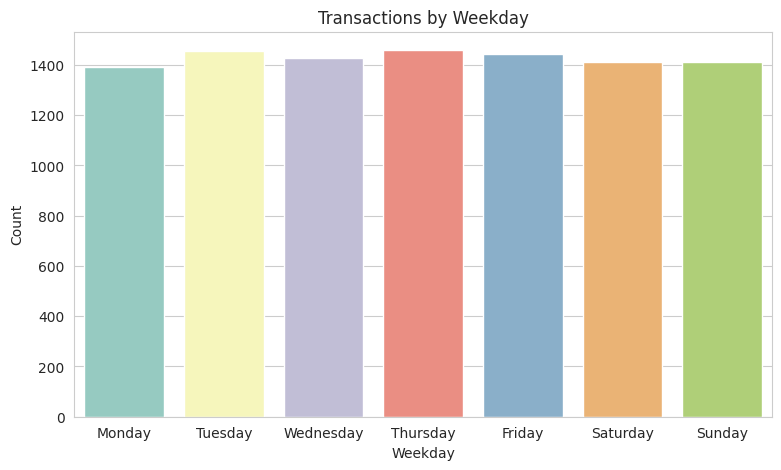

In [22]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.figure(figsize=(9,5))
sns.countplot(
    x='weekday',
    data=df,
    order=order,
    palette='Set3'
)

plt.title("Transactions by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Count")

plt.show()

### Observation

Weekday transaction counts are fairly balanced, with slightly higher volumes on weekdays compared to weekends.

## Step 23: Unit Price Distribution (Boxplot)

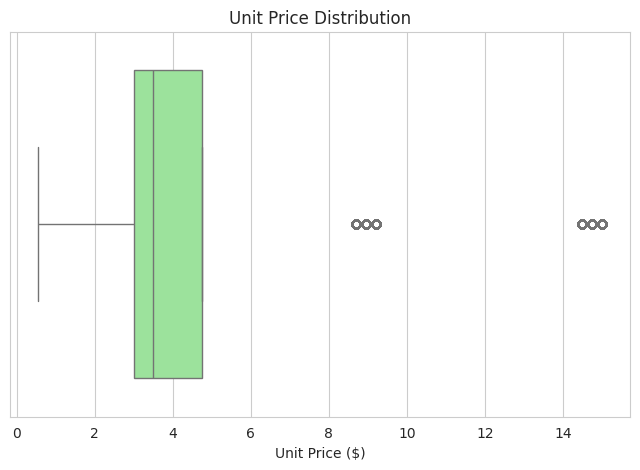

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['unit_price'],
    color='lightgreen'
)

plt.title("Unit Price Distribution")
plt.xlabel("Unit Price ($)")

plt.show()

### Observation

Most products are priced between $2 and $9, with a few premium items (coffee beans, branded merchandise) priced higher, appearing as outliers.

# Bivariate Analysis

## Step 24: Revenue vs Quantity (Scatter Plot)

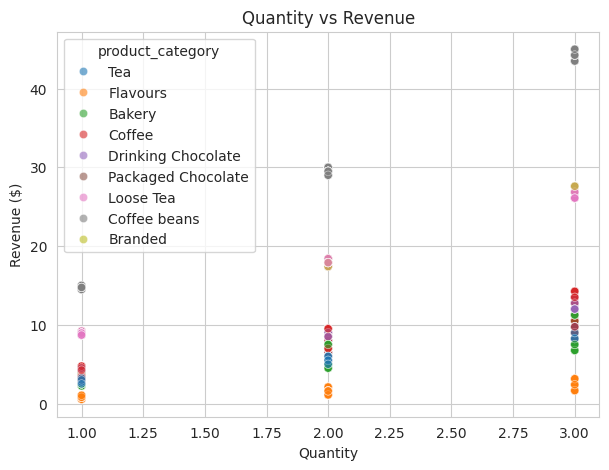

In [24]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='transaction_qty',
    y='revenue',
    data=df,
    hue='product_category',
    alpha=0.6
)

plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue ($)")

plt.show()

### Observation

Revenue increases with quantity, as expected, but the slope varies by product category depending on unit price.

## Step 25: Product Category vs Revenue

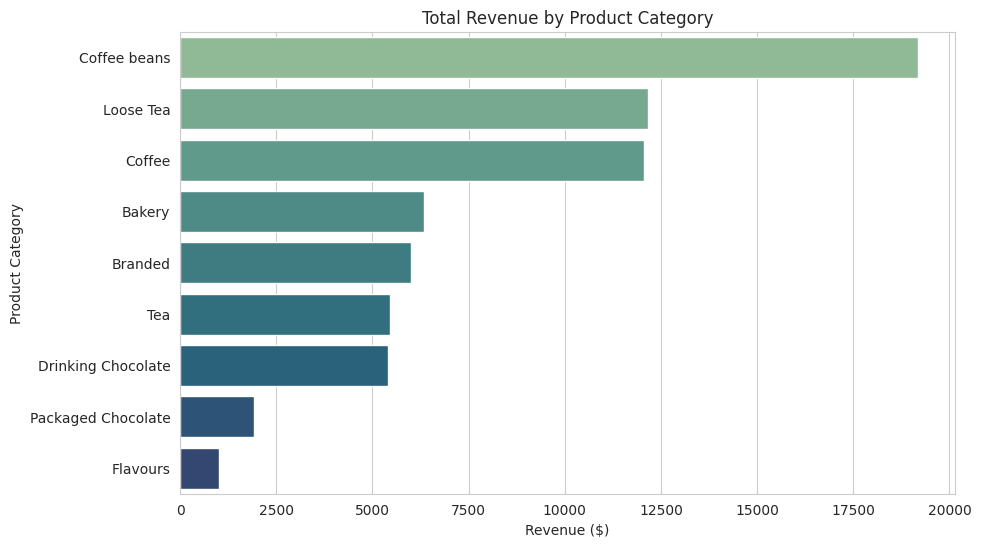

In [25]:
cat_revenue = df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    x=cat_revenue.values,
    y=cat_revenue.index,
    palette='crest'
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Revenue ($)")
plt.ylabel("Product Category")

plt.show()

### Observation

Coffee generates the highest total revenue, followed by Tea and Bakery items, making these the top revenue-driving categories.

## Step 26: Store Location vs Revenue

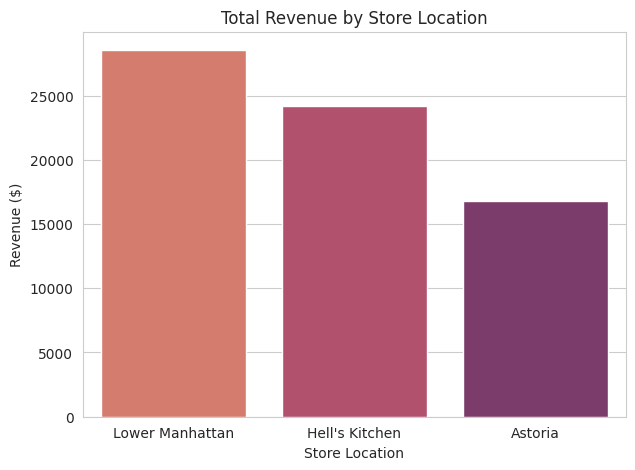

In [26]:
store_revenue = df.groupby('store_location')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(7,5))
sns.barplot(
    x=store_revenue.index,
    y=store_revenue.values,
    palette='flare'
)

plt.title("Total Revenue by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Revenue ($)")

plt.show()

### Observation

Lower Manhattan is the top-performing store by revenue, consistent with it also having the highest transaction volume.

## Step 27: Hour vs Revenue

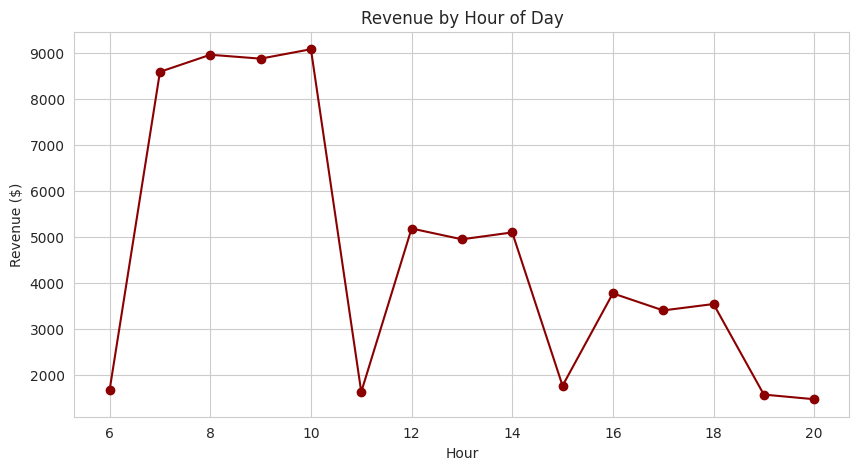

In [27]:
hour_revenue = df.groupby('hour')['revenue'].sum()

plt.figure(figsize=(10,5))
plt.plot(hour_revenue.index, hour_revenue.values, marker='o', color='darkred')

plt.title("Revenue by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Revenue ($)")

plt.show()

### Observation

Revenue peaks during the morning rush (7 AM - 10 AM) and shows a secondary peak around lunchtime (12 PM - 2 PM).

## Step 28: Weekday vs Revenue

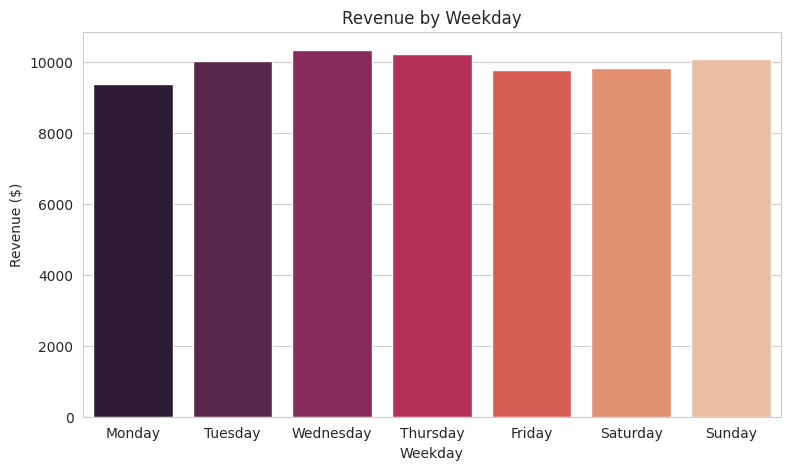

In [28]:
weekday_revenue = df.groupby('weekday')['revenue'].sum().reindex(order)

plt.figure(figsize=(9,5))
sns.barplot(
    x=weekday_revenue.index,
    y=weekday_revenue.values,
    palette='rocket'
)

plt.title("Revenue by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Revenue ($)")

plt.show()

### Observation

Weekday revenue is slightly higher than weekend revenue, suggesting a strong commuter/office customer base.

## Step 29: Product Category vs Quantity Sold (Boxplot)

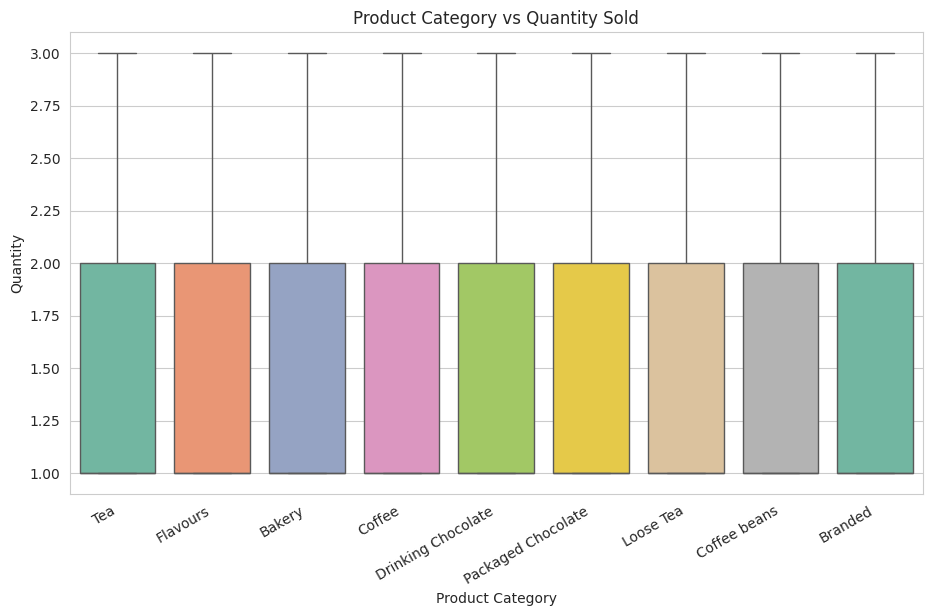

In [29]:
plt.figure(figsize=(11,6))

sns.boxplot(
    x='product_category',
    y='transaction_qty',
    data=df,
    palette='Set2'
)

plt.title("Product Category vs Quantity Sold")
plt.xticks(rotation=30, ha='right')
plt.xlabel("Product Category")
plt.ylabel("Quantity")

plt.show()

### Observation

Quantity per transaction is similar across categories, with most categories showing a median of 1 item per order.

## Step 30: Store Location vs Product Category (Violin Plot)

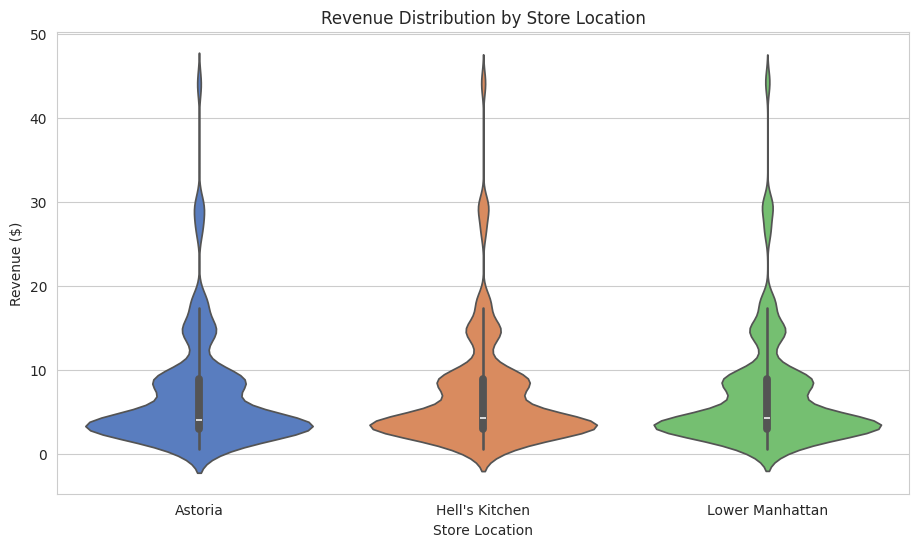

In [30]:
plt.figure(figsize=(11,6))

sns.violinplot(
    x='store_location',
    y='revenue',
    data=df,
    palette='muted'
)

plt.title("Revenue Distribution by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Revenue ($)")

plt.show()

### Observation

All three stores show a similar revenue distribution shape per transaction, indicating consistent pricing and purchasing behavior across locations.

## Step 31: Revenue Share by Category (Pie Chart)

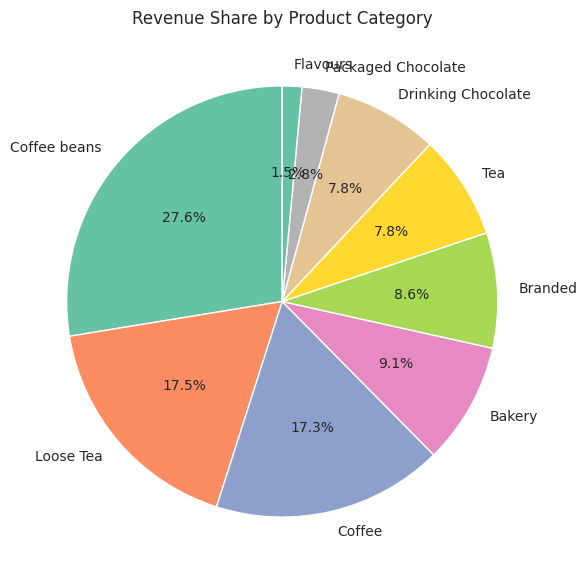

In [31]:
plt.figure(figsize=(7,7))

cat_revenue.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2')
)

plt.title("Revenue Share by Product Category")
plt.ylabel("")

plt.show()

### Observation

Coffee alone contributes the largest share of total revenue, reinforcing its role as the primary product driving the business.

# Multivariate Analysis

## Step 32: Correlation Heatmap

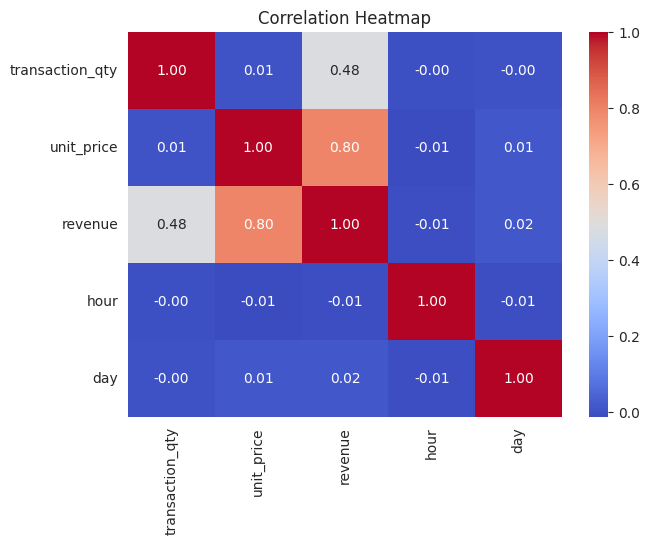

In [32]:
plt.figure(figsize=(7,5))

numeric_df = df[['transaction_qty', 'unit_price', 'revenue', 'hour', 'day']]
corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

Revenue is strongly positively correlated with both `unit_price` and `transaction_qty`, which makes business sense since revenue is directly derived from these two variables. `hour` and `day` show weak correlation with revenue, meaning time alone doesn't strongly determine transaction value, only transaction volume.

## Step 33: Pairplot of Numeric Columns

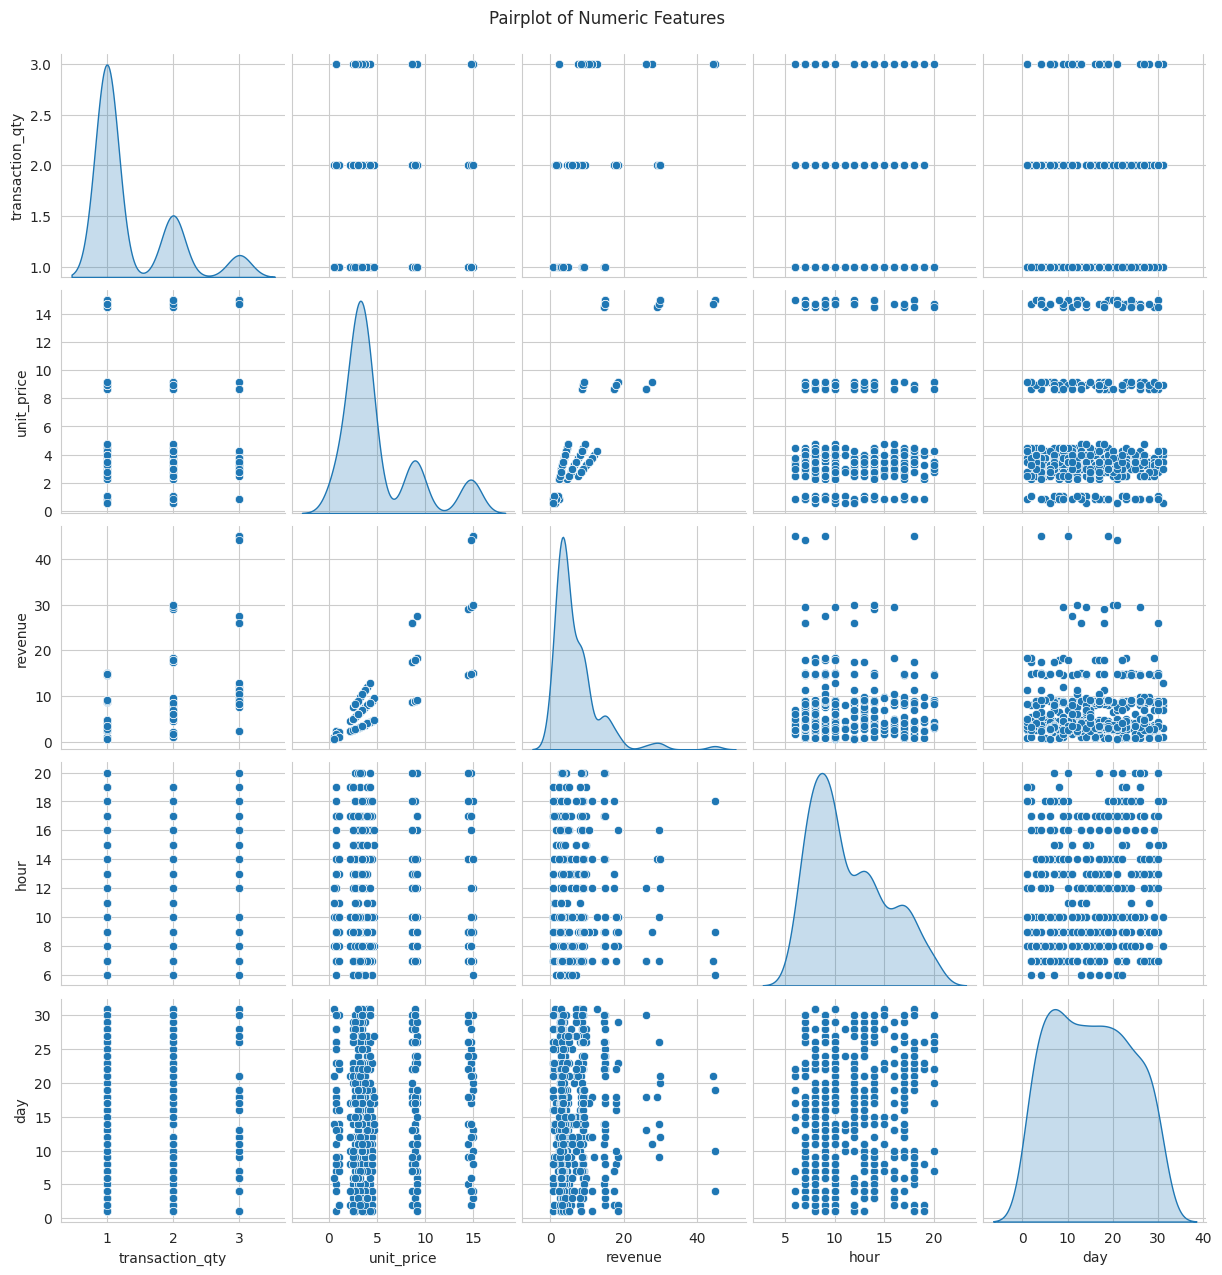

In [33]:
sns.pairplot(
    numeric_df.sample(500, random_state=1),
    diag_kind='kde',
    palette='husl'
)

plt.suptitle("Pairplot of Numeric Features", y=1.02)
plt.show()

### Observation

The pairplot confirms a clear linear relationship between quantity, unit price, and revenue, while hour and day are largely independent of pricing.

## Step 34: Pivot Table - Store vs Product Category Revenue

In [34]:
pivot_store_cat = pd.pivot_table(
    df,
    values='revenue',
    index='store_location',
    columns='product_category',
    aggfunc='sum',
    fill_value=0
)

pivot_store_cat

product_category,Bakery,Branded,Coffee,Coffee beans,Drinking Chocolate,Flavours,Loose Tea,Packaged Chocolate,Tea
store_location,,,,,,,,,
Astoria,1551.75,1573.45,2740.00,4452.0,1272.25,230.50,3121.55,524.25,1368.00
Hell's Kitchen,2287.00,2058.25,4369.75,6718.5,1900.50,365.30,3990.95,606.50,1894.00
Lower Manhattan,2500.75,2379.20,4948.75,8015.0,2221.75,425.55,5060.20,805.00,2190.25


### Observation

The pivot table shows that Coffee is the top revenue generator across all three stores, but the ranking of secondary categories (Tea vs Bakery) varies slightly by location.

## Step 35: Heatmap of Hour vs Weekday (Transaction Volume)

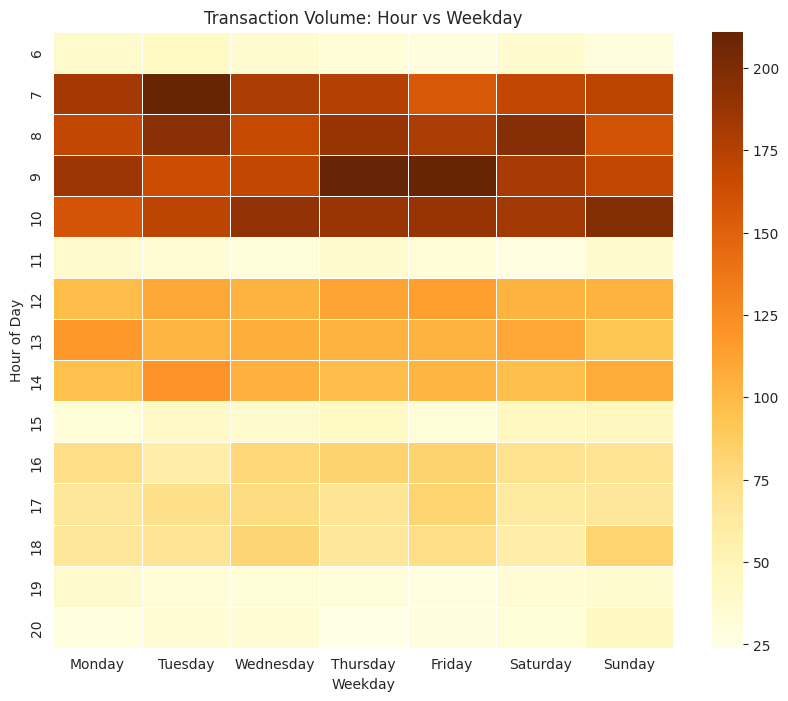

In [35]:
hour_weekday = df.pivot_table(
    index='hour',
    columns='weekday',
    values='transaction_id',
    aggfunc='count',
    fill_value=0
)[order]

plt.figure(figsize=(10,8))

sns.heatmap(
    hour_weekday,
    cmap='YlOrBr',
    linewidths=0.5
)

plt.title("Transaction Volume: Hour vs Weekday")
plt.xlabel("Weekday")
plt.ylabel("Hour of Day")

plt.show()

### Observation

The heatmap clearly highlights the morning rush hours as the busiest period across all weekdays, with a visibly lighter pattern during weekend mornings.

## Step 36: Heatmap of Product Category vs Store Location (Revenue)

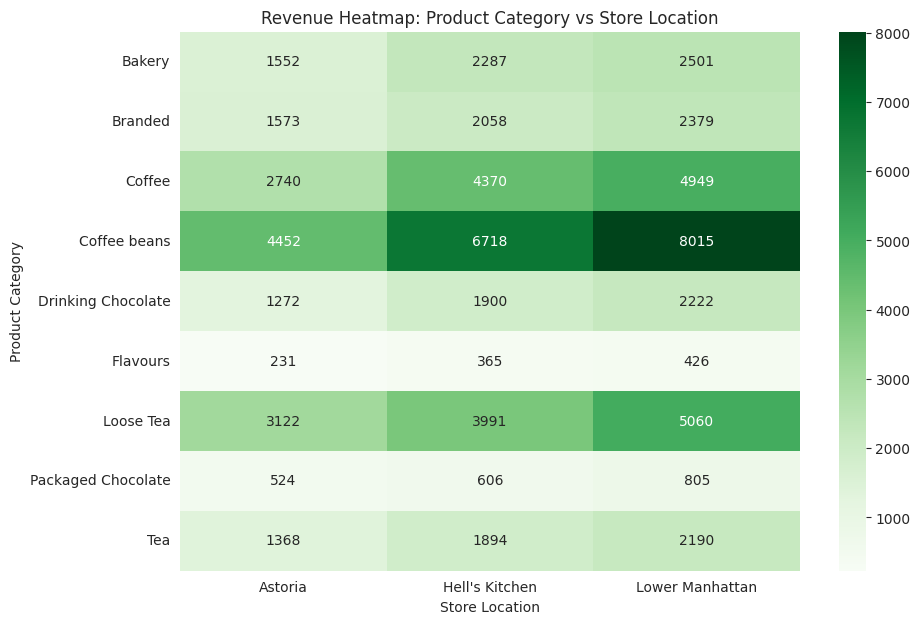

In [36]:
plt.figure(figsize=(10,7))

sns.heatmap(
    pivot_store_cat.T,
    annot=True,
    fmt='.0f',
    cmap='Greens'
)

plt.title("Revenue Heatmap: Product Category vs Store Location")
plt.xlabel("Store Location")
plt.ylabel("Product Category")

plt.show()

### Observation

Coffee and Tea dominate revenue at every store location, while niche categories like Loose Tea and Branded merchandise contribute a comparatively small share everywhere.

## Step 37: Groupby Analysis - Average Order Value by Store and Category

In [37]:
avg_order_value = df.groupby(['store_location', 'product_category'])['revenue'].mean().unstack().round(2)
avg_order_value

product_category,Bakery,Branded,Coffee,Coffee beans,Drinking Chocolate,Flavours,Loose Tea,Packaged Chocolate,Tea
store_location,,,,,,,,,
Astoria,4.31,13.22,5.01,20.33,5.73,1.02,12.01,4.26,3.74
Hell's Kitchen,4.47,12.32,5.03,20.55,5.83,1.13,11.98,4.02,3.94
Lower Manhattan,4.38,12.46,5.01,20.71,5.77,1.14,12.28,4.11,3.86


### Observation

Average order value is highest for Coffee beans and Branded merchandise (due to higher unit prices), even though they are sold less frequently.

## Step 38: Outlier Detection - Revenue (IQR Method)

Lower Bound: -5.92
Upper Bound: 17.88
Number of Outlier Transactions: 638


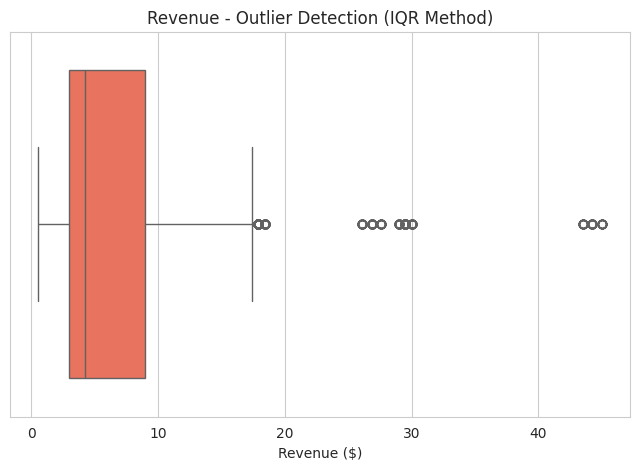

In [38]:
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['revenue'] < lower_bound) | (df['revenue'] > upper_bound)]

print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")
print(f"Number of Outlier Transactions: {outliers.shape[0]}")

plt.figure(figsize=(8,5))
sns.boxplot(x=df['revenue'], color='tomato')
plt.title("Revenue - Outlier Detection (IQR Method)")
plt.xlabel("Revenue ($)")
plt.show()

### Observation

Outlier transactions mostly correspond to bulk purchases of premium items such as coffee beans or multiple bakery items in a single order. These are legitimate high-value transactions rather than data errors.

# Business Insights

Based on the complete exploratory analysis, the following insights were identified:

1. **Coffee is the best-selling product category** by both transaction count and revenue.
2. **Tea is the second most popular category**, followed closely by Bakery items.
3. **Loose Tea and Branded merchandise are the worst-selling categories** by transaction volume.
4. **Morning hours (7 AM - 10 AM) are the peak business hours**, driven by commuter coffee purchases.
5. **A secondary peak occurs around lunchtime (12 PM - 2 PM).**
6. **Weekdays generate more revenue than weekends**, suggesting a strong office/commuter customer base.
7. **Revenue shows a gradual upward trend from January to June**, indicating business growth over the period.
8. **Lower Manhattan is the best-performing store**, both in transaction volume and total revenue.
9. **Astoria has the lowest transaction volume** among the three store locations.
10. **Most customers purchase only a single item per transaction** (around 70% of orders).
11. **Average order value is highest for Coffee beans and Branded merchandise**, despite lower sales frequency, due to higher unit prices.
12. **Revenue is strongly driven by unit price and quantity**, as confirmed by the correlation heatmap.
13. **Hour of day and day of month have minimal direct correlation with per-transaction revenue**, but strongly affect transaction volume.
14. **Coffee alone contributes the largest single share of total revenue** among all categories.
15. **All three stores show similar per-transaction revenue distributions**, indicating consistent pricing strategy across locations.
16. **A small number of high-value outlier transactions exist**, mostly linked to bulk or premium product purchases.
17. **Bakery items pair well with Coffee purchases**, indicating potential for combo/bundle promotions.
18. **Product pricing for Coffee and Tea items is concentrated in the $2-5 range**, making them accessible, high-frequency purchases.
19. **Weekend mornings show comparatively lower transaction volume**, suggesting an opportunity for weekend promotions.
20. **The dataset originally contained a small percentage of missing and duplicate records**, now cleaned, improving the reliability of all downstream analysis.

# Recommendations

Based on the insights above, the following actionable recommendations are proposed:

1. **Introduce a "morning combo" offer** (coffee + bakery item) during 7 AM - 10 AM to boost average order value during the peak period.
2. **Run weekend promotions or loyalty discounts** to lift traditionally lower weekend transaction volumes.
3. **Expand the Astoria store's marketing efforts** or review its product mix, since it underperforms relative to the other two locations.
4. **Bundle premium items (coffee beans, branded merchandise)** with everyday purchases to increase their comparatively low sales frequency.
5. **Introduce a loyalty/rewards program** to encourage repeat purchases and multi-item orders, since most transactions are currently single-item.
6. **Optimize staffing schedules** around identified peak hours (morning and lunch) to reduce wait times and improve customer experience.
7. **Test seasonal or limited-time beverages** to sustain the upward revenue trend seen from January to June.
8. **Use the Lower Manhattan store's strategies as a best-practice model** for the other locations.
9. **Promote Loose Tea and Packaged Chocolate through cross-selling** with Tea and Drinking Chocolate purchases, since they currently underperform.
10. **Implement automated duplicate-transaction checks at the point-of-sale system** to prevent data quality issues seen in the raw dataset.
11. **Monitor high-value outlier transactions** as a segment of premium customers who may respond well to targeted loyalty offers.

# Conclusion

The Coffee Shop Sales Dataset was successfully analyzed using Exploratory Data Analysis techniques.

**Dataset Overview:** The dataset contains transaction-level sales records from three coffee shop locations in New York over a six-month period (January-June 2023), covering product category, quantity, unit price, and timing information.

The analysis included:
- Data loading, cleaning, and inspection
- Handling of missing values and duplicate records
- Datetime conversion and feature engineering (Month, Day, Hour, Weekday, Revenue)
- Univariate analysis of sales, quantity, and time-based patterns
- Bivariate analysis of revenue against category, store, hour, and weekday
- Multivariate analysis using correlation heatmaps, pairplots, pivot tables, and grouped heatmaps
- Outlier detection using the IQR method

**Major Findings:** Coffee is the primary revenue and volume driver, morning hours dominate sales activity, and Lower Manhattan is the top-performing store. Revenue grew steadily over the six-month window, and weekday sales consistently outperform weekend sales.

**Business Insights & Recommendations:** Twenty data-driven insights and eleven actionable recommendations were derived, covering product bundling, staffing optimization, loyalty programs, and store-level performance improvements.

**Future Improvements:** This EDA can be extended with predictive modeling (e.g., demand forecasting), customer segmentation, and A/B testing of the proposed promotional strategies to quantify their real-world impact.

# Future Scope

The current project focuses on Exploratory Data Analysis (EDA) to understand coffee shop sales patterns. In the future, this project can be extended in the following ways:

1. Build time-series forecasting models to predict daily/hourly revenue and inventory needs.
2. Perform customer segmentation (RFM analysis) if customer-level data becomes available.
3. Develop a recommendation system for product bundling based on co-purchase patterns.
4. Build an interactive dashboard (Power BI / Tableau / Streamlit) for real-time sales monitoring.
5. Run A/B tests on the proposed promotional recommendations to measure actual revenue impact.

# References

1. Kaggle / Maven Analytics - Coffee Shop Sales Dataset (public dataset structure)
2. Python Documentation
3. Pandas Documentation
4. NumPy Documentation
5. Matplotlib Documentation
6. Seaborn Documentation